In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.io import wavfile
from scipy import signal

try:
    import sounddevice as sd
except Exception:
    sd = None

try:
    from pydub import AudioSegment
except Exception:
    AudioSegment = None

Книга 

http://www.dspguide.com/about.htm

Образцы звуков

https://freewavesamples.com/

Документация в помощь

https://www.kaggle.com/code/ilyamich/mfcc-implementation-and-tutorial

https://prosound.ixbt.com/education/spektr-analys.shtml

https://opensource.com/article/19/9/audio-processing-machine-learning-python


Некоторые важные функции и преобразования данных, важные для обработки речи и звука:

1. Mel-frequency cepstral coefficients (MFCCs) Мел-кепстральные коэффициенты
1. Gammatone-frequency cepstral coefficients (GFCCs) Гамматон-частотные кепстральные коэффициенты
1. Linear-prediction cepstral coefficients (LFCCs)  Линейно-частотные кепстральных коэффициентов
1. Bark-frequency cepstral coefficients (BFCCs) 
1. Power-normalized cepstral coefficients (PNCCs) Нормированные по мощности кепстральные коэффициенты
1. Spectrum  Спектр
1. Sepstrum  Kепстр
1. Spectrogram  Cпектрограмма

# Что такое спектр и кепстр?

Спектр и кепстр — две особенно важные функции обработки звука.

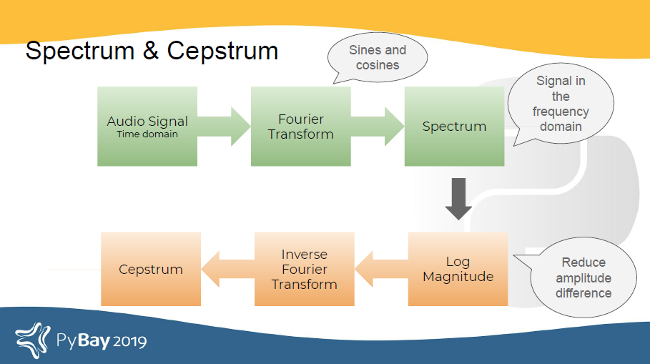

Математически спектр — это преобразование Фурье сигнала. Преобразование Фурье преобразует сигнал временной области в частотную область. Другими словами, спектр — это представление в частотной области входного аудиосигнала во временной области.

Кепстр формируется путем взятия логарифмической величины спектра с последующим обратным преобразованием Фурье. В результате получается сигнал, который не находится ни в частотной области (поскольку мы использовали обратное преобразование Фурье), ни во временной области (поскольку мы взяли логарифмическую величину до обратного преобразования Фурье). Область результирующего сигнала называется квенренцией.


Причина, по которой нас волнует сигнал в частотной области, связана с биологией уха. Прежде чем мы сможем обрабатывать и интерпретировать звук, должно произойти много вещей. Один из них происходит в улитке — заполненной жидкостью части уха с тысячами крошечных волосков, связанных с нервами. Некоторые волоски короткие, а некоторые относительно длиннее. Более короткие волосы резонируют с более высокими звуковыми частотами, а более длинные — с более низкими звуковыми частотами. Таким образом, ухо похоже на естественный анализатор с преобразованием Фурье!

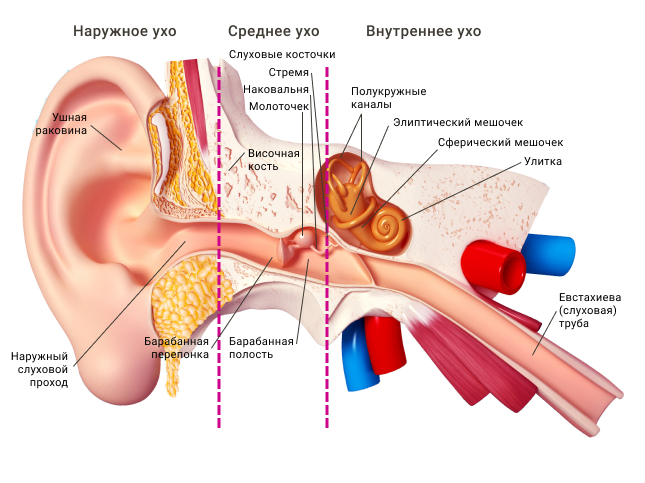

Еще один факт о человеческом слухе заключается в том, что по мере увеличения частоты звука выше 1 кГц наши уши становятся менее избирательными к частотам. Это хорошо соответствует так называемому банку фильтров Мела.

А вообще мы можем слышать только в диапазоне частот от 20 до 20000 Hz


In [2]:
f = 'data/Alesis-S4-Plus-Clean-Gtr-C4.wav'

samplerate, data = wavfile.read(f)
data_ch0 = data[:, 0] if np.ndim(data) > 1 else data

print('Sampling Rate:', samplerate)
print('Audio Shape:', np.shape(data))

Sampling Rate: 44100
Audio Shape: (110250,)


samplerate - частота дискретизации (или частота семплирования, англ. sample rate) — частота взятия отсчётов непрерывного по времени сигнала при его дискретизации (в частности, аналого-цифровым преобразователем). Измеряется в герцах.

In [3]:
duration = len(data)/samplerate
time = np.arange(0,duration,1/samplerate) #time vector

print(f"длительность {duration} \n временная шкала {time}")

длительность 2.5 
 временная шкала [0.00000000e+00 2.26757370e-05 4.53514739e-05 ... 2.49993197e+00
 2.49995465e+00 2.49997732e+00]


In [4]:
type(data)

numpy.ndarray

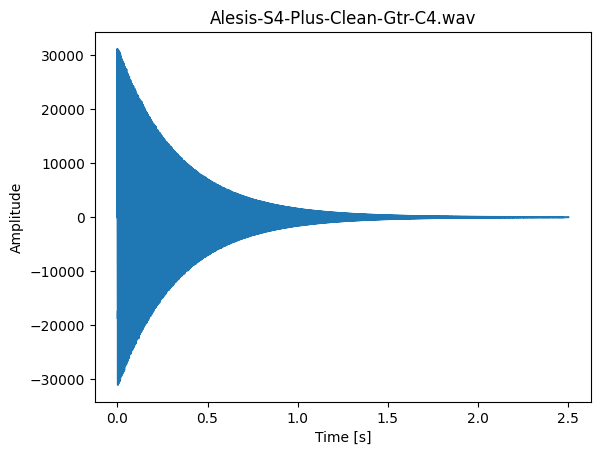

In [5]:

plt.plot(time, data)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Alesis-S4-Plus-Clean-Gtr-C4.wav')
plt.show()

In [ ]:
if sd is None:
    print('sounddevice is unavailable, skip audio playback.')
else:
    try:
        sd.play(data_ch0, samplerate)
        sd.wait()
    except Exception as e:
        print(f'Playback skipped: {e}')

sounddevice is unavailable, skip audio playback.


## Stereo to Mono

Sampling Rate: 44100
Audio Shape: (110250,)


C:\Users\alex\AppData\Local\Temp\ipykernel_15244\2035003552.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(t, a, 'k-', color='purple')


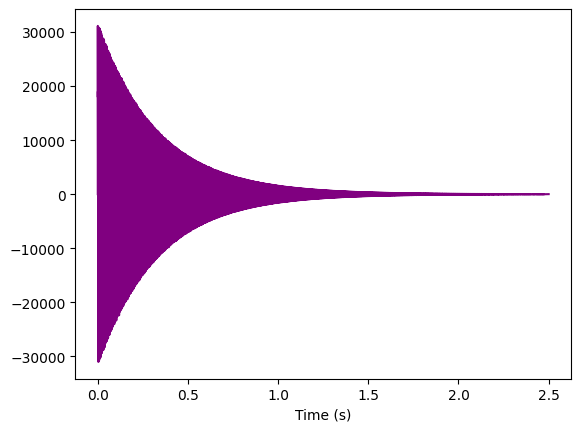

In [7]:
if AudioSegment is not None:
    asegment = AudioSegment.from_wav(f)
    asegment = asegment.set_channels(1)
    asegment.export('mono.wav', format='wav')
else:
    # Fallback conversion without pydub
    mono = data_ch0.astype(data.dtype)
    wavfile.write('mono.wav', samplerate, mono)

s, a = wavfile.read('mono.wav')
print('Sampling Rate:', s)
print('Audio Shape:', np.shape(a))

duration = len(data_ch0) / samplerate
time = np.arange(0, duration, 1 / samplerate)

na = data_ch0.shape[0]
la = na / s
t = np.linspace(0, la, na)
plt.plot(t, a, 'k-', color='purple')
plt.xlabel('Time (s)')
plt.show()

# Спектрограмма

Спектрограмма - зависимость спектральной плотности мощности сигнала от времени. Она отображает мощность частоты в каждом временном отрезке. Естественный логарифм спектрограммы улучшает видимость частотного содержания, так что несколько больших пиков не снижают разрешение всей спектрограммы.

Спектрограмма  - двумерная диаграмма: 

на горизонтальной оси представлено время, по вертикальной оси — частота; третье измерение с указанием амплитуды на определенной частоте в конкретный момент времени представлено интенсивностью или цветом каждой точки изображения.

Спектрограмма сигнала s(t) может быть оценена путём вычисления квадрата амплитуды оконного преобразования Фурье сигнала s(t), следующим образом:

$
{\mathrm  {spectrogram}}(t,\omega )=\left|{\mathrm  {STFT}}(t,\omega )\right|^{2}
$

Создание спектрограммы с помощью оконного преобразования Фурье обычно выполняется методами цифровой обработки. Производится цифровая выборка данных во временной области. Сигнал разбивается на части, которые, как правило, перекрываются, и затем производится преобразование Фурье, чтобы рассчитать величину частотного спектра для каждой части. Каждая часть соответствует вертикальной линии на изображении — значение амплитуды в зависимости от частоты в каждый момент времени.

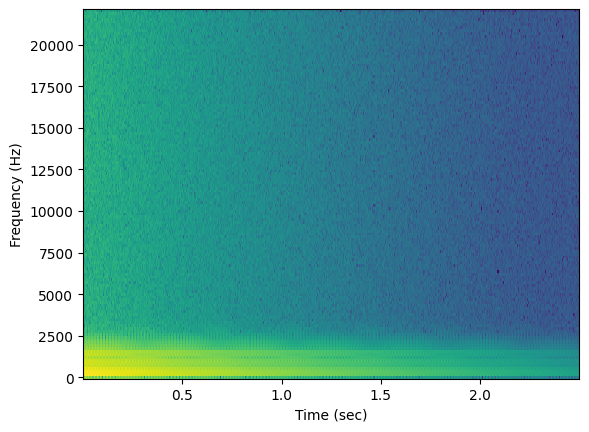

In [8]:
adata = data_ch0
s = samplerate

fr, tm, spgram = signal.spectrogram(adata, s)
lspg = np.log(spgram)
plt.pcolormesh(tm, fr, lspg, shading='auto')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (sec)')
plt.show()

# Быстрое преобразование Фурье (FFT)

Быстрое преобразование Фурье (FFT) – алгоритм, который позволяет вычислить частотный спектр сигнала.
Это один из алгоритмов вычисления дискретного преобразования Фурье.

Нужны 2 функции:

fft() вычисляет быстрое преобразование Фурье.

fftfreq() находит частоты в центре каждого «бина» на выходе fft(). Бин - интервал группировки значений.

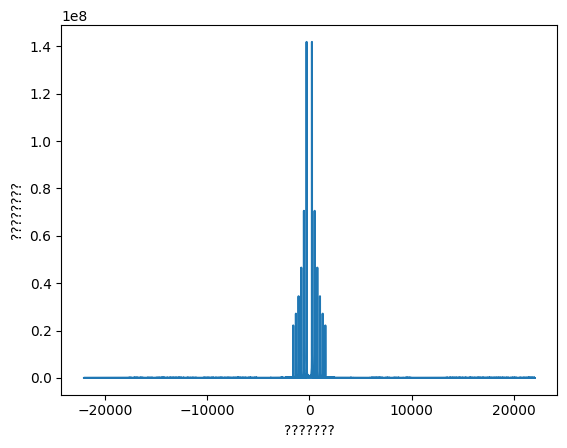

In [ ]:
from scipy.fft import fft, fftfreq

N = int(samplerate * duration)

yf = fft(data_ch0)
xf = fftfreq(N, 1 / samplerate)

plt.plot(xf, np.abs(yf))
plt.xlabel('???????')
plt.ylabel('????????')
plt.show()

Максимальная частота - 22050 Гц. Это значение составляет ровно половину частоты дискретизации и называется *частотой Найквиста*.

Это соответствует фундаментальной теореме обработки сигналов (теорема Котельникова, теорема Найквиста — Шеннона, теорема отсчётов):

**Любую функцию F(t), состоящую из частот от 0 до 1 до f_1, можно непрерывно передавать с любой точностью при помощи чисел, следующих друг за другом менее чем через  1/(2f_1) секунд.**

 То есть частота дискретизации должна как минимум вдвое превышать максимальную частоту сигнала.

In [10]:
np.max(xf)

np.float64(22049.600000000002)

In [11]:
samplerate

44100

Частотный спект получился симметричным. То есть можно вычислить только одну часть частотного спектра.

Это можно сделать с помощью функции rfft().



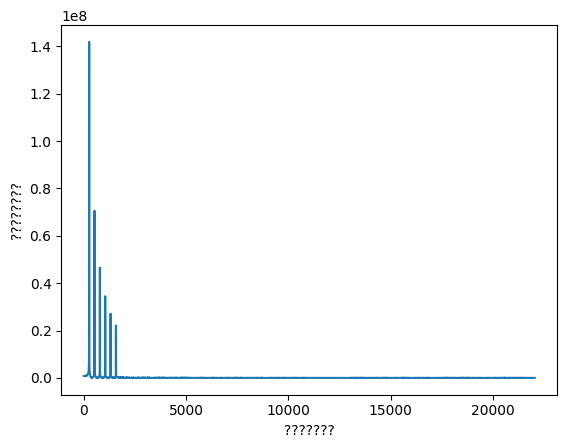

In [12]:
from scipy.fft import rfft, rfftfreq

# ????? ????? ? normalized_tone
rN = int(samplerate * duration)

ryf = rfft(data_ch0)
rxf = rfftfreq(rN, 1 / samplerate)

plt.plot(rxf, np.abs(ryf))
plt.xlabel('???????')
plt.ylabel('????????')
plt.show()

 Преобразовании Фурье обратимо. Любой сигнал, измененный в частотной области, можно преобразовать обратно во временную область.

 Это можно использовать для фильтрации сигнала. 

 Попробуем отфильтровать частоту 4998.663426488456 Гц

In [13]:
# Максимальная частота составляет половину частоты дискретизации
points_per_freq = len(rxf) / (samplerate / 2)

# Наша целевая частота 
target_idx = int(points_per_freq * 4998.663426488456)

target_idx1 = int(points_per_freq * 10000)

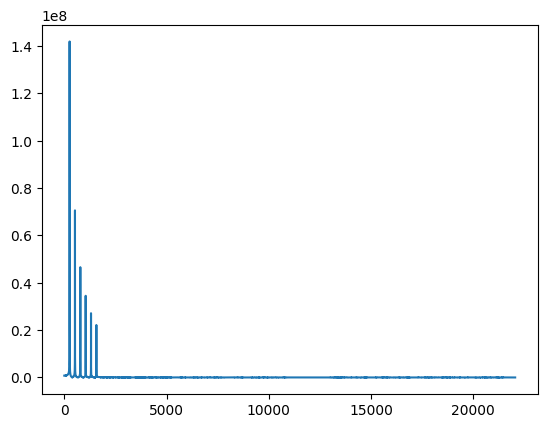

In [14]:
ryf[target_idx-2:target_idx+2] = 0


plt.plot(rxf, np.abs(ryf))
plt.show()

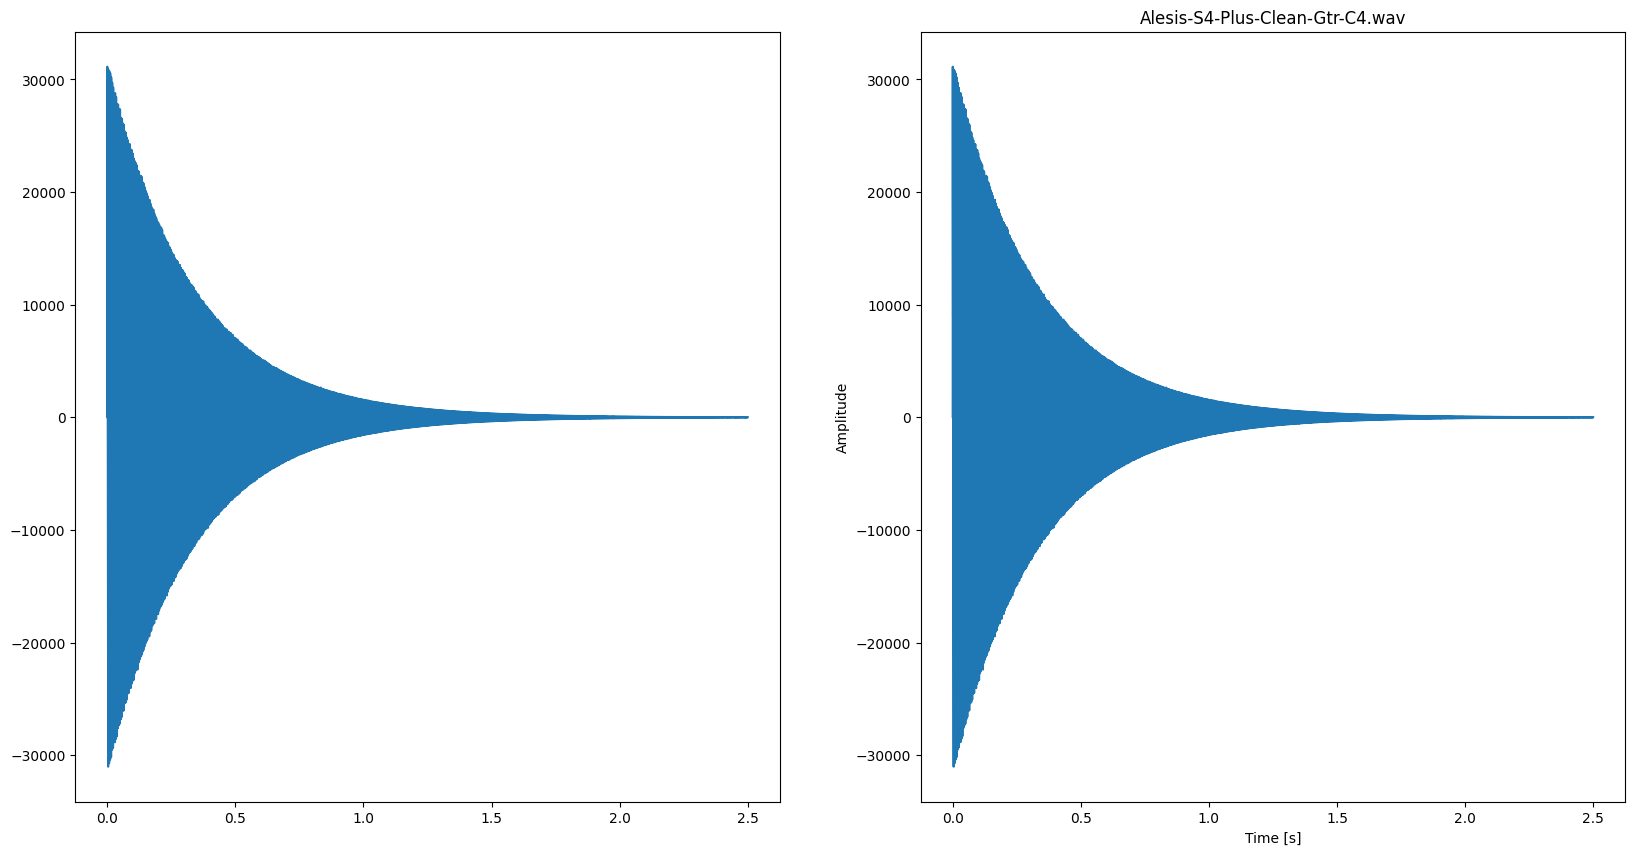

In [15]:
from scipy.fft import irfft

new_sig = irfft(ryf)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

ax[0].plot(time, data_ch0)
ax[1].plot(time, new_sig)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Alesis-S4-Plus-Clean-Gtr-C4.wav')
plt.show()

In [16]:
# ???????, ??? ??????????
if sd is None:
    print('sounddevice is unavailable, skip audio playback.')
else:
    try:
        sd.play(data_ch0, samplerate)
        sd.wait()
        sd.play(new_sig, samplerate)
        sd.wait()
    except Exception as e:
        print(f'Playback skipped: {e}')

sounddevice is unavailable, skip audio playback.


# Дискретное косинусное преобразование   (англ. Discrete Cosine Transform, DCT)
Один из видов FFT

 Используется
 Обработка аудиосигнала — кодирование звука, сжатие аудиоданных (с потерями и без них), объемный звук, акустическое эхо и отмена обратной связи, фонема распознавание, отмена сглаживания во временной области (TDAC)
   1. Цифровой звук
   1. Цифровое радио — Цифровое звуковое вещание (DAB+), HD-радио
   1. Обработка речи — кодирование речи, распознавание речи, обнаружение голосовой активности (VAD)
   1. Цифровая телефония — передача голоса по IP (VoIP), мобильная телефония, видеотелефония, телеконференции, видеоконференции


А также во многих других областях - в работе с видео и изображениями, криптографии, биометрии, медицинских данных, и т.д.

Как и любое преобразование, связанное с Фурье, дискретные косинусоидальные преобразования (DCT) выражают функцию или сигнал в терминах суммы синусоид с различными частотами и амплитудами. Подобно дискретному преобразованию Фурье (DFT), DCT оперирует функцией с конечным числом дискретных точек данных. Очевидное различие между DCT и DFT заключается в том, что первое использует только косинусные функции, в то время как второе использует как косинусы, так и синусы (в форме комплексных экспонент). Однако это видимое различие является всего лишь следствием более глубокого различия: DCT подразумевает граничные условия, отличные от DFT или других связанных преобразований.

Связанные с Фурье преобразования, которые воздействуют на функцию в конечной области, такие как DFT или DCT или ряд Фурье, можно рассматривать как неявно определяющие расширение этой функции за пределы области. То есть, как только вы записываете функцию f(x) в виде суммы синусоид, вы можете вычислить эту сумму в любое время x, даже для x тех f(x) случаев, когда исходное значение не было указано. DFT, как и ряд Фурье, подразумевает периодическое расширение исходной функции. DCT, как и косинусное преобразование, подразумевает четное расширение исходной функции.

Формально дискретное косинусное преобразование является линейной обратимой функцией 
$
{\displaystyle f:\mathbb {R} ^{N} \to \mathbb {R} ^{N}} 
$
(где 
$
{\displaystyle \mathbb {R} } $ обозначает множество действительных чисел) или, что эквивалентно, обратимой N × N квадратной матрицей. Существует несколько вариантов DCT со слегка измененными определениями. N действительных чисел $
{\displaystyle ~x_{0},\ \ldots \ x_{N-1}~}$ преобразуются в N действительных чисел 
$
{\displaystyle X_{0},\,\ldots,\,X_{N-1}}$ в соответствии с одной из формул:

DCT - I

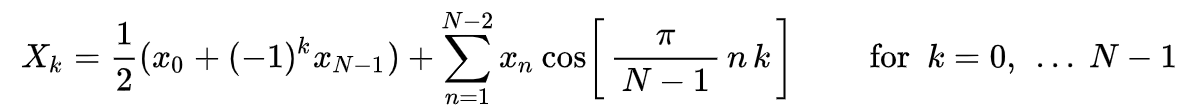

DCT - II

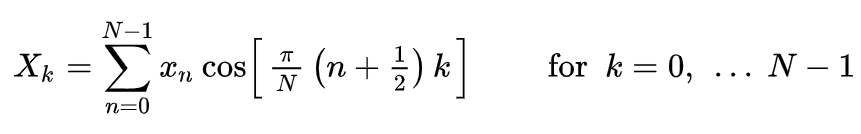

DCT - III

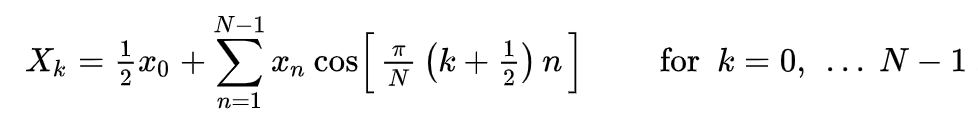

DCT - IV

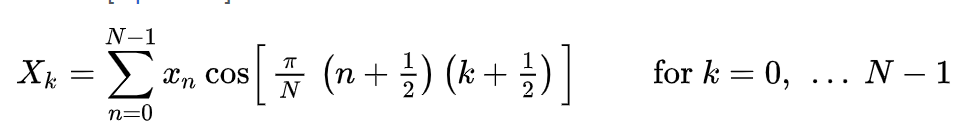

# Мел-кепстральные коэффициенты (MFCC)

Мел – единица высоты звука, основанная на восприятии этого звука нашими органами слуха. Как известно, АЧХ человеческого уха даже отдаленно не напоминает прямую, и амплитуда – не совсем точная мера громкости звука. Поэтому, и ввели эмпирически подобранные единицы громкости, например, фон


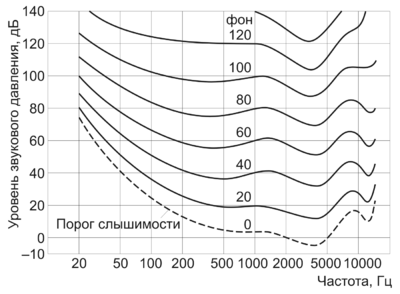

Воспринимаемая человеческим слухом высота звука не совсем линейно зависит от его частоты.

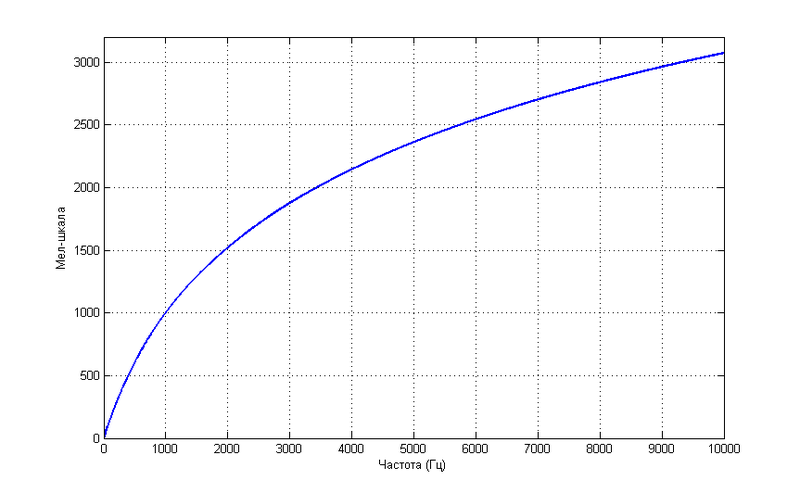
 
m = 1125 ln(1 + f/700)

# Кепстр

Кепстр — один из видов гомоморфной обработки сигналов, функция обратного преобразования Фурье от логарифма спектра мощности сигнала


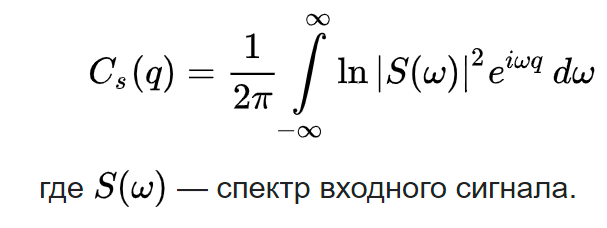

где $ S(\omega ) $— спектр входного сигнала.

Аргумент q имеет размерность времени, но это особое, кепстральное время, поскольку 
$
{\displaystyle C_{s}(q)}$ в любой момент  q зависит от функции $
{\displaystyle s(t)}$ исходного сигнала со спектром ${\displaystyle S(\omega ),}$ заданной при ${\displaystyle -\infty <t<\infty }$ 

Иногда q называют «сачтота» или «кьюфренси» (анаграммы от рус. частота или англ. frequency).

# Как получить мел-коэффициенты?


1. Исходный сигнал



2. Преобразовние Фурье

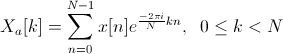

3. Гребенка фильтров на основе оконной функции

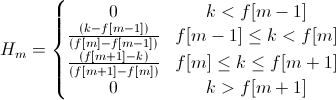

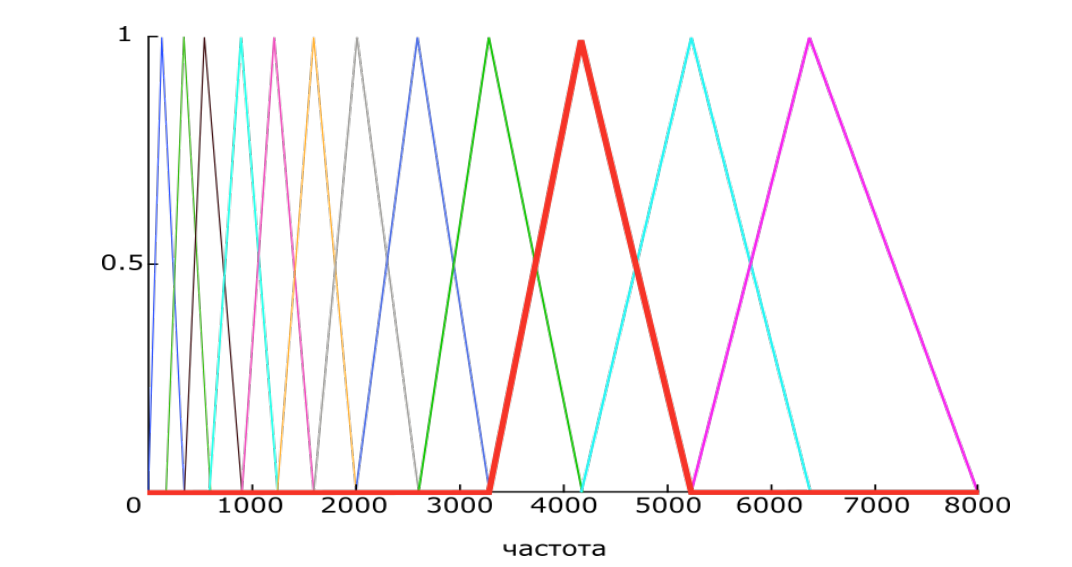
Фильтры собираются в области низких частот, обеспечивая более высокое "разрешение" там, где это
необходимо для распознавания

Частоты получаются на основе формул

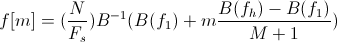

m - номер окна

M - количество окон

f1 - самая низкая частота проектного фильтра

fn - самая высокая частота проектного фильтра

Fs - частота дискретизации

Преобразование в мел-шкалу



4.  Вычисляем энергию для каждого окна

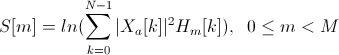


5. Применяем ДКП

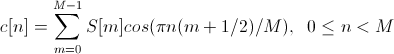

Получаем набор MFCC


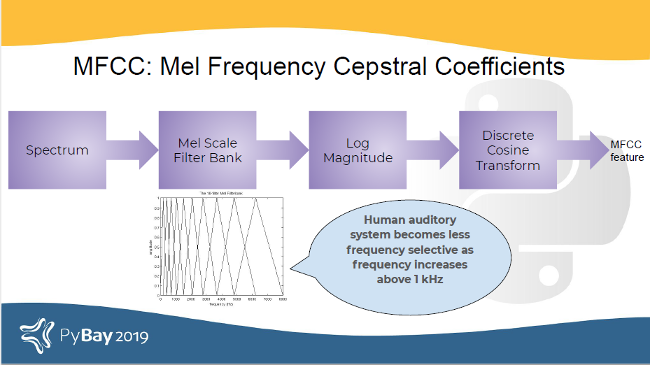

# Gammatone-frequency cepstral coefficients (GFCCs) Гамматон-частотные кепстральные коэффициенты

Еще один фильтр, вдохновленный человеческим слухом, — это набор фильтров Gammatone. Этот банк фильтров используется в качестве внешнего моделирования улитки. 

Eго цель — воспроизвести то, как мы слышим.

GFCC формируются путем пропускания спектра через блок фильтров Gammatone с последующим сжатием громкости и DCT. Первые (приблизительно) 22 функции называются GFCC. GFCC имеют ряд применений в обработке речи, например, идентификация говорящего.


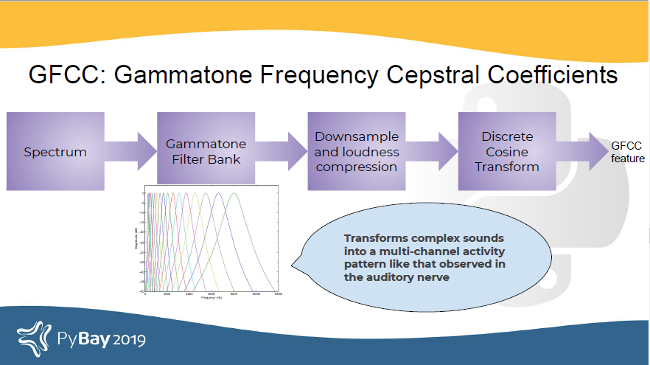

# Создание классификатора

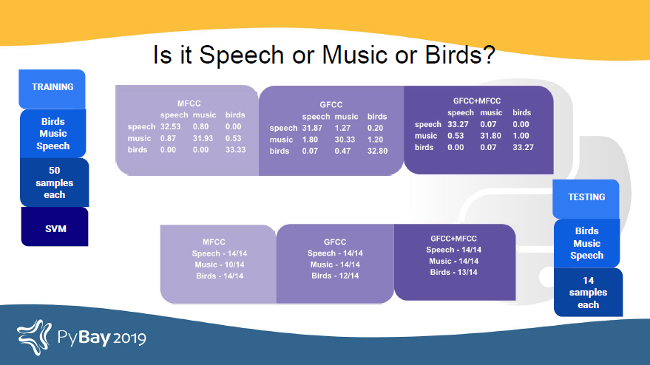

In [17]:
import librosa

samples, sample_rate = librosa.load("data/Alesis-S4-Plus-Clean-Gtr-C4.wav")

y = samples
sr = sample_rate
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10)

In [18]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=20000)


C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


[Text(0.5, 1.0, 'MFCC')]

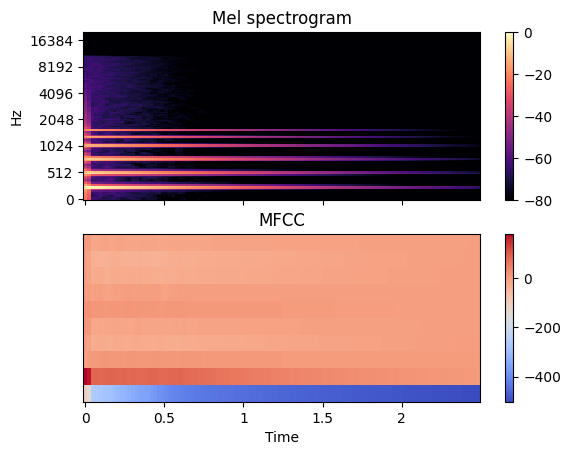

In [19]:
fig, ax = plt.subplots(nrows=2, sharex=True)
img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=20000,
                               ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = librosa.display.specshow(mfccs, x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')

In [20]:
mfccs

array([[-104.74812  , -140.84253  , -260.22556  , ..., -499.7224   ,
        -500.27115  , -500.92117  ],
       [ 178.28653  ,  165.38521  ,   85.47928  , ...,    6.95565  ,
           6.3638034,    5.7788653],
       [  -9.460886 ,    4.250009 ,    5.85242  , ...,    4.104847 ,
           3.9173079,    4.0516768],
       ...,
       [  -4.57856  ,   -7.7064133,  -24.64364  , ...,   -1.4730283,
          -1.4934422,   -1.4050517],
       [  -3.1680622,   -7.0645475,  -29.270119 , ...,   -1.839128 ,
          -1.7484131,   -1.5832542],
       [   4.81127  ,    3.4082959,  -14.506376 , ...,   -2.0981455,
          -1.9356849,   -1.811521 ]], shape=(10, 108), dtype=float32)

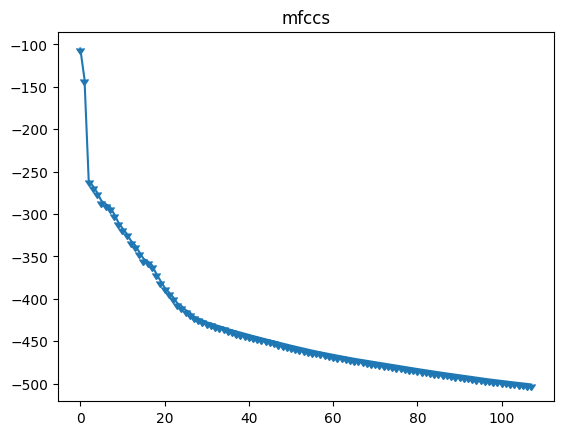

In [21]:
s = mfccs[0, :]
t = np.arange(len(s))
plt.plot(t, s, marker=matplotlib.markers.CARETDOWNBASE)
plt.title('mfccs')
plt.show()

In [22]:
from python_speech_features import mfcc
from python_speech_features import logfbank
import scipy.io.wavfile as wav

(rate,sig) = wav.read("data/1980s-Casio-Violin-C5.wav")
mfcc_feat = mfcc(sig,rate)
fbank_feat = logfbank(sig,rate)

print(fbank_feat[1:3,:])

[[ 8.395832    8.67325392  9.90280609 15.069605   15.11318456 11.59456389
  15.25977008 14.71714069 15.35854983 14.98748587 15.44728102 15.57904163
  15.5311511  15.65172598 14.16382766  9.78547783  8.74304195  8.05514762
   7.57482365  7.15928477  6.89403962  6.71460319  6.58250473  6.47700482
   6.44834056  6.39120473]
 [ 8.01844167  8.4470394   9.94581055 15.92867028 15.95685465 12.09583669
  16.06391687 15.49513266 16.17570496 15.79115264 16.26716293 16.40702673
  16.29781936 16.50322969 14.94671817 10.08410386  8.77213779  7.8265658
   7.09782939  6.47942067  5.99328039  5.58548701  5.33595595  5.01498203
   4.78632809  4.67047483]]


# Упражнения

1. Запишите два разных звука 
1. Вычислить их спектральные характеристики (спектр, MFCC, GFCC) 
1. Построение спектрограммы 
1. Проанализируйте их сходства и различия

In [23]:
# Решения к лабораторной 13: аудио как временной ряд
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import rfft, rfftfreq
from scipy.spatial.distance import cosine, cdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from spafe.features.gfcc import gfcc as spafe_gfcc
except Exception:
    spafe_gfcc = None

try:
    import seaborn as sns
except Exception:
    sns = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [24]:
# Подготовка упражнений: 2 исходных звука + генерация дополнительных примеров
path_1 = "data/Alesis-S4-Plus-Clean-Gtr-C4.wav"
path_2 = "data/1980s-Casio-Violin-C5.wav"

sr = 22050
y1, _ = librosa.load(path_1, sr=sr, mono=True)
y2, _ = librosa.load(path_2, sr=sr, mono=True)

print(f"Источник 1: {path_1}, отсчетов={len(y1)}, sr={sr}")
print(f"Источник 2: {path_2}, отсчетов={len(y2)}, sr={sr}")


def normalize_audio(y):
    y = np.asarray(y, dtype=np.float32)
    denom = np.max(np.abs(y)) + 1e-8
    return y / denom


def make_segments(y, sr, clip_sec=1.2, step_sec=0.45, max_segments=6):
    n = int(clip_sec * sr)
    step = int(step_sec * sr)
    y = normalize_audio(y)
    segments = []
    for start in range(0, max(1, len(y) - n + 1), max(1, step)):
        seg = y[start : start + n]
        if len(seg) == n:
            segments.append(seg)
        if len(segments) >= max_segments:
            break
    if not segments:
        segments = [normalize_audio(y[:n])]
    return segments


def add_noise(y, noise_level=0.012):
    noise = np.random.normal(0.0, noise_level, size=len(y))
    return normalize_audio(y + noise)


records = []
for source_name, y in [("guitar", y1), ("violin", y2)]:
    segments = make_segments(y, sr, clip_sec=1.2, step_sec=0.45, max_segments=6)
    for i, seg in enumerate(segments):
        records.append(
            {
                "clip_id": f"{source_name}_clean_{i}",
                "source": source_name,
                "variant": "clean",
                "signal": seg,
            }
        )
        records.append(
            {
                "clip_id": f"{source_name}_noisy_{i}",
                "source": source_name,
                "variant": "noisy",
                "signal": add_noise(seg, noise_level=0.012),
            }
        )

print(f"Сформировано аудио-фрагментов: {len(records)}")
print(pd.DataFrame(records)[["clip_id", "source", "variant"]].head(8))


Источник 1: data/Alesis-S4-Plus-Clean-Gtr-C4.wav, отсчетов=55125, sr=22050
Источник 2: data/1980s-Casio-Violin-C5.wav, отсчетов=55125, sr=22050
Сформировано аудио-фрагментов: 12
          clip_id  source variant
0  guitar_clean_0  guitar   clean
1  guitar_noisy_0  guitar   noisy
2  guitar_clean_1  guitar   clean
3  guitar_noisy_1  guitar   noisy
4  guitar_clean_2  guitar   clean
5  guitar_noisy_2  guitar   noisy
6  violin_clean_0  violin   clean
7  violin_noisy_0  violin   noisy


In [25]:
# Вспомогательные функции: сигнал, спектр, спектрограмма, MFCC, GFCC, статистики
def magnitude_spectrum(y, sr):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    spec = np.abs(rfft(y))
    freq = rfftfreq(n, 1 / sr)
    return freq, spec


def compute_features(y, sr, n_mfcc=13, n_gfcc=13):
    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256)) ** 2
    S_db = librosa.power_to_db(S, ref=np.max)
    mfcc_feat = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    if spafe_gfcc is not None:
        gfcc_feat = spafe_gfcc(y, fs=sr, num_ceps=n_gfcc).T
    else:
        # Fallback, если spafe недоступен: используем Mel-банки как замену.
        mel_fb = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_gfcc)
        gfcc_feat = librosa.power_to_db(mel_fb + 1e-8)

    centroid = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    rolloff = float(librosa.feature.spectral_rolloff(y=y, sr=sr).mean())
    bandwidth = float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    zcr = float(librosa.feature.zero_crossing_rate(y=y).mean())
    rms = float(librosa.feature.rms(y=y).mean())

    return {
        "S_db": S_db,
        "mfcc": mfcc_feat,
        "gfcc": gfcc_feat,
        "centroid": centroid,
        "rolloff": rolloff,
        "bandwidth": bandwidth,
        "zcr": zcr,
        "rms": rms,
    }


def plot_waveform(y, sr, title):
    time = np.arange(len(y)) / sr
    plt.figure(figsize=(10.8, 2.6))
    plt.plot(time, y)
    plt.title(title)
    plt.xlabel("Время, с")
    plt.ylabel("Амплитуда")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_spectrum(freq, spec, title):
    plt.figure(figsize=(10.8, 2.6))
    plt.plot(freq, spec)
    plt.xlim(0, sr / 2)
    plt.title(title)
    plt.xlabel("Частота, Гц")
    plt.ylabel("Модуль")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_feature_map(feature, title, sr, hop=256, mode="coef"):
    plt.figure(figsize=(10.8, 2.8))
    if mode == "spec":
        librosa.display.specshow(feature, sr=sr, hop_length=hop, x_axis="time", y_axis="hz")
    else:
        plt.imshow(feature, aspect="auto", origin="lower", interpolation="nearest")
        plt.xlabel("Кадр")
        plt.ylabel("Индекс коэффициента")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


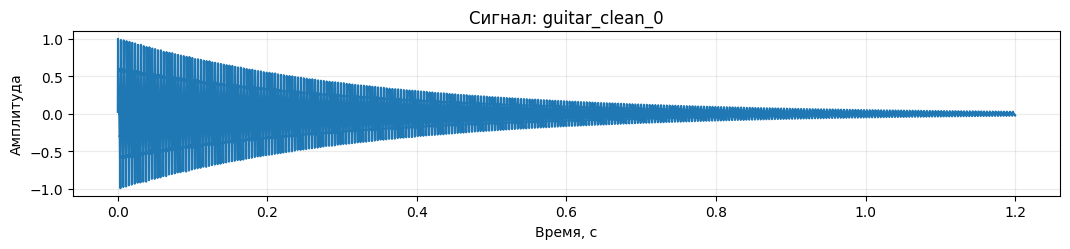

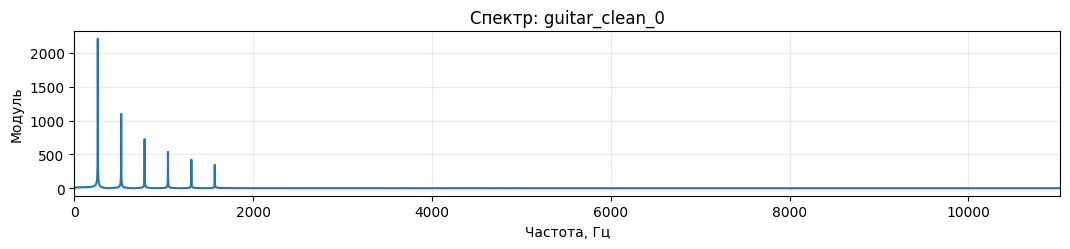

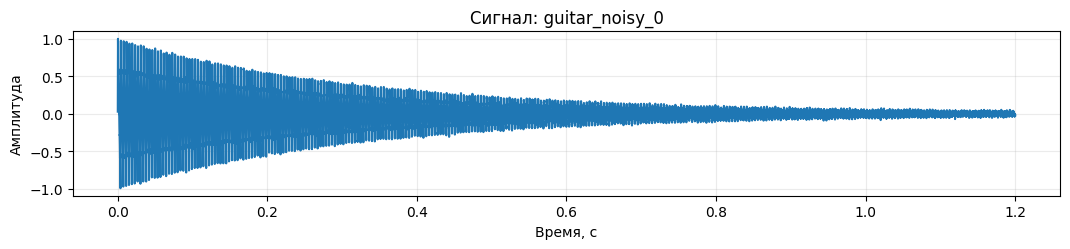

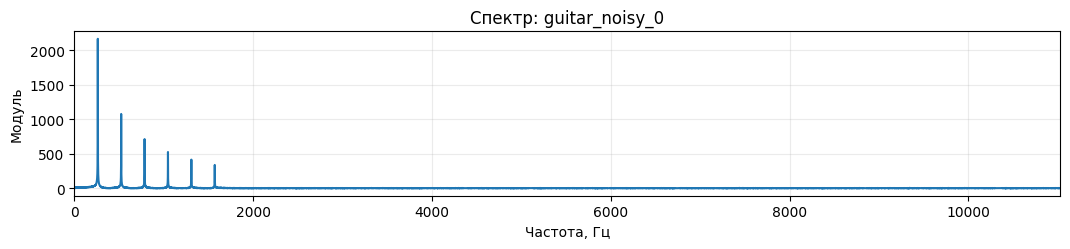

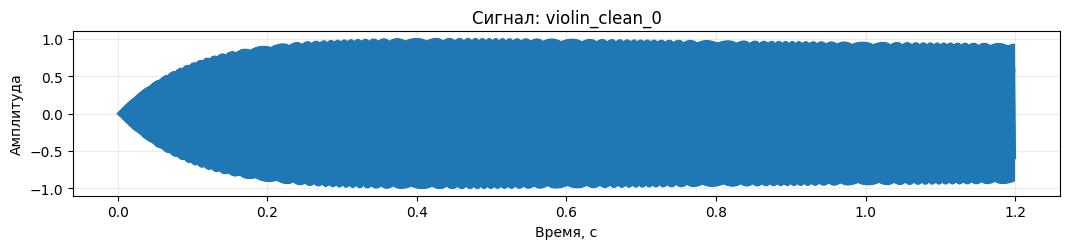

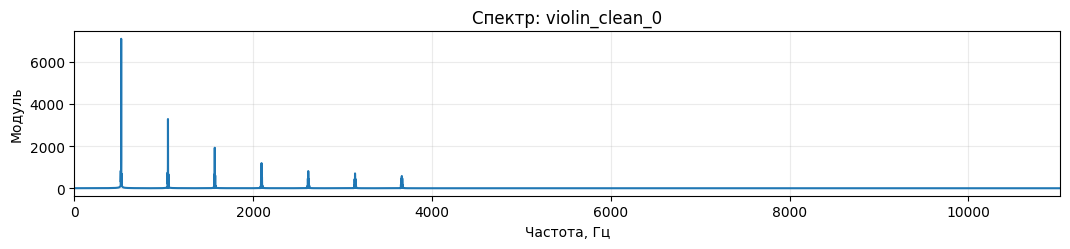

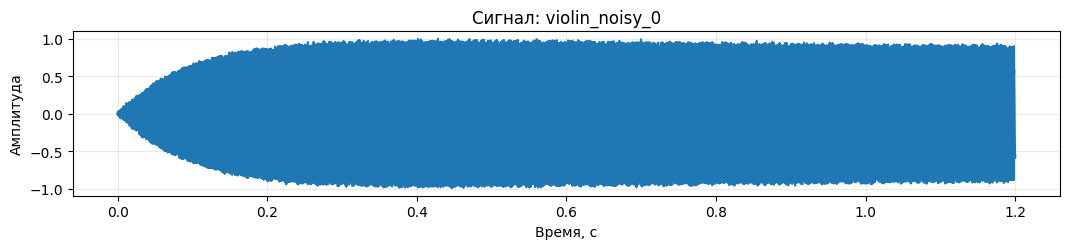

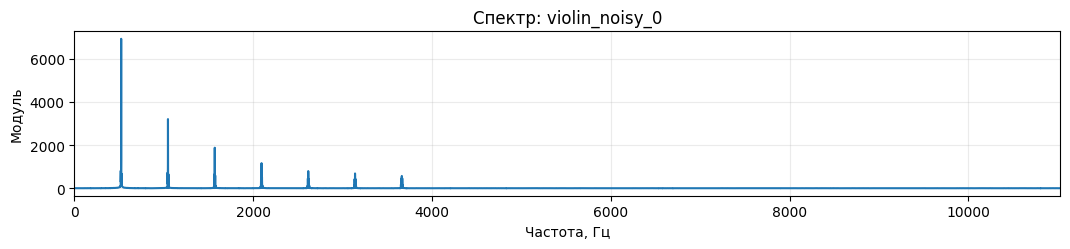

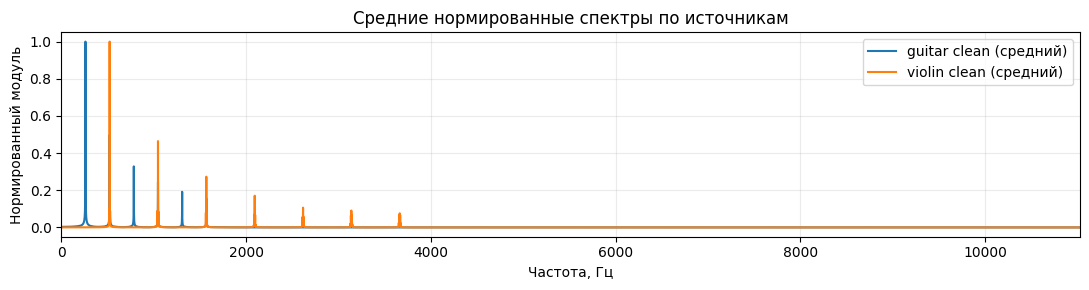

In [26]:
# 1) Волны и спектры: показываем больше примеров из разных источников/вариантов
example_ids = [
    ("guitar", "clean", 0),
    ("guitar", "noisy", 0),
    ("violin", "clean", 0),
    ("violin", "noisy", 0),
]

for source_name, variant, idx in example_ids:
    rec = next(r for r in records if r["source"] == source_name and r["variant"] == variant and r["clip_id"].endswith(f"_{idx}"))
    y = rec["signal"]
    plot_waveform(y, sr, f"Сигнал: {rec['clip_id']}")
    f, spec = magnitude_spectrum(y, sr)
    plot_spectrum(f, spec, f"Спектр: {rec['clip_id']}")

# Усредненный спектр по классам (clean-варианты), чтобы сравнить общую форму.
def average_spectrum(records_subset):
    specs = []
    freq_ref = None
    for r in records_subset:
        f, s = magnitude_spectrum(r["signal"], sr)
        if freq_ref is None:
            freq_ref = f
        specs.append(s / (np.max(s) + 1e-8))
    return freq_ref, np.mean(np.vstack(specs), axis=0)

guitar_clean = [r for r in records if r["source"] == "guitar" and r["variant"] == "clean"]
violin_clean = [r for r in records if r["source"] == "violin" and r["variant"] == "clean"]

fg, sg = average_spectrum(guitar_clean)
fv, sv = average_spectrum(violin_clean)

plt.figure(figsize=(11, 3))
plt.plot(fg, sg, label="guitar clean (средний)")
plt.plot(fv, sv, label="violin clean (средний)")
plt.xlim(0, sr / 2)
plt.title("Средние нормированные спектры по источникам")
plt.xlabel("Частота, Гц")
plt.ylabel("Нормированный модуль")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


,clip_id,source,variant,centroid,rolloff,bandwidth,zcr,rms
0,guitar_clean_0,guitar,clean,927.692092,1332.366943,1404.120672,0.032950,0.144526
1,guitar_noisy_0,guitar,noisy,3210.970075,7051.709923,3151.260766,0.090501,0.142944
2,guitar_clean_1,guitar,clean,926.776628,1318.287541,1409.597265,0.033954,0.037501
3,guitar_noisy_1,guitar,noisy,4404.366664,8737.718318,3368.045057,0.215219,0.151560
4,guitar_clean_2,guitar,clean,926.303225,1312.904241,1409.956321,0.037297,0.009701
5,guitar_noisy_2,guitar,noisy,5130.167252,9185.774583,3297.530093,0.368080,0.191966
6,violin_clean_0,violin,clean,1427.126301,2629.742432,1005.517231,0.046396,0.473002
7,violin_noisy_0,violin,noisy,2131.705687,3821.936505,2211.106055,0.047786,0.462253
8,violin_clean_1,violin,clean,1423.022021,2621.046330,1004.033804,0.046377,0.492237
9,violin_noisy_1,violin,noisy,2049.791060,3589.419321,2146.174755,0.046377,0.483906


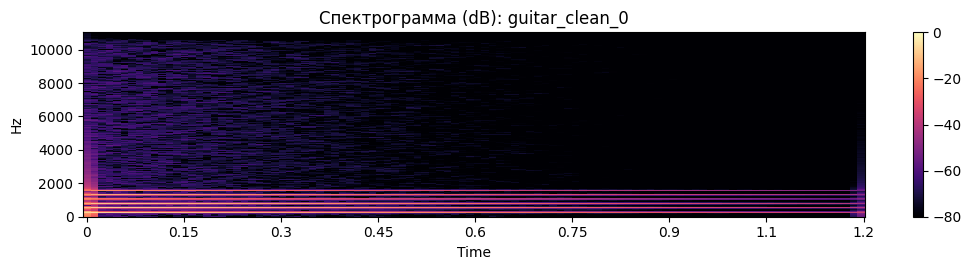

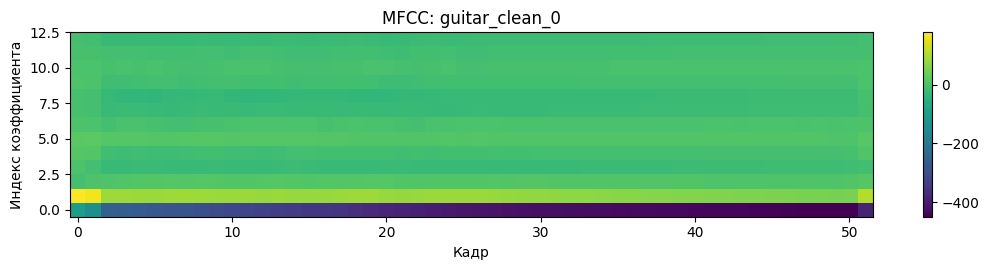

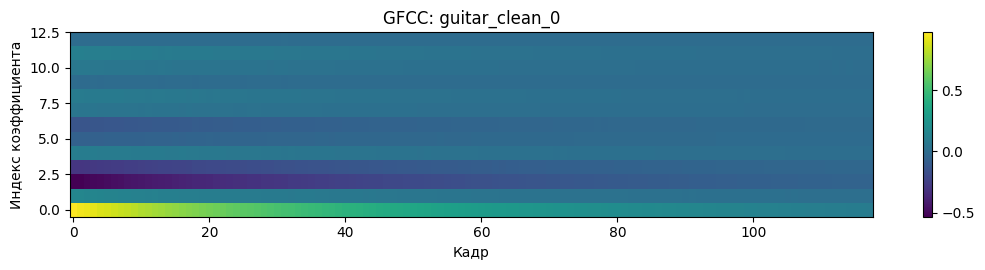

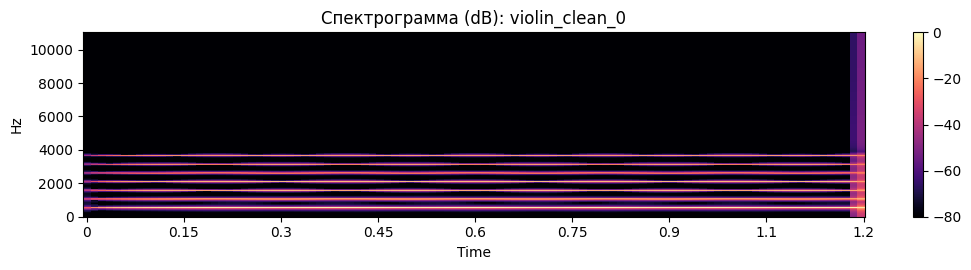

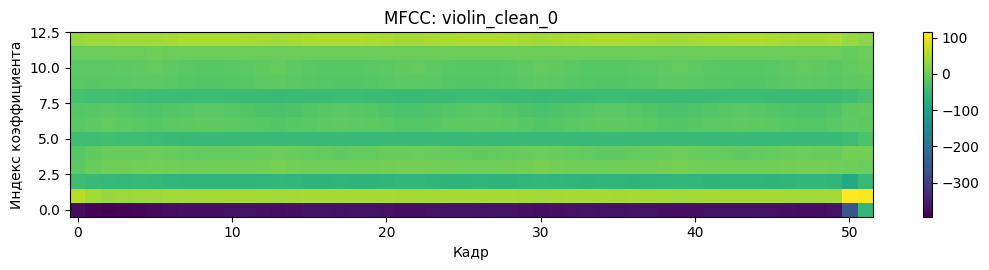

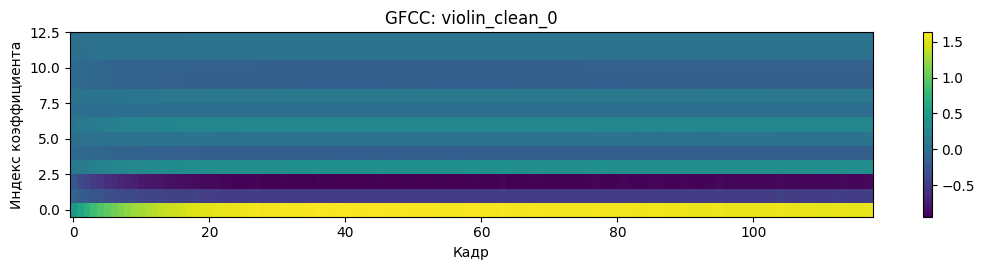

In [27]:
# 2) MFCC/GFCC и 3) спектрограммы для всех записей + визуализация представителей
feature_rows = []

for r in records:
    feats = compute_features(r["signal"], sr)
    r["features"] = feats

    mfcc_mean = feats["mfcc"].mean(axis=1)
    mfcc_std = feats["mfcc"].std(axis=1)
    gfcc_mean = feats["gfcc"].mean(axis=1)
    gfcc_std = feats["gfcc"].std(axis=1)

    emb = np.concatenate([mfcc_mean, mfcc_std, gfcc_mean, gfcc_std])
    r["embedding"] = emb

    feature_rows.append(
        {
            "clip_id": r["clip_id"],
            "source": r["source"],
            "variant": r["variant"],
            "centroid": feats["centroid"],
            "rolloff": feats["rolloff"],
            "bandwidth": feats["bandwidth"],
            "zcr": feats["zcr"],
            "rms": feats["rms"],
        }
    )

features_df = pd.DataFrame(feature_rows)
display(features_df.head(10))

for source_name in ["guitar", "violin"]:
    rec = next(r for r in records if r["source"] == source_name and r["variant"] == "clean")
    feats = rec["features"]
    plot_feature_map(feats["S_db"], f"Спектрограмма (dB): {rec['clip_id']}", sr=sr, mode="spec")
    plot_feature_map(feats["mfcc"], f"MFCC: {rec['clip_id']}", sr=sr, mode="coef")
    plot_feature_map(feats["gfcc"], f"GFCC: {rec['clip_id']}", sr=sr, mode="coef")


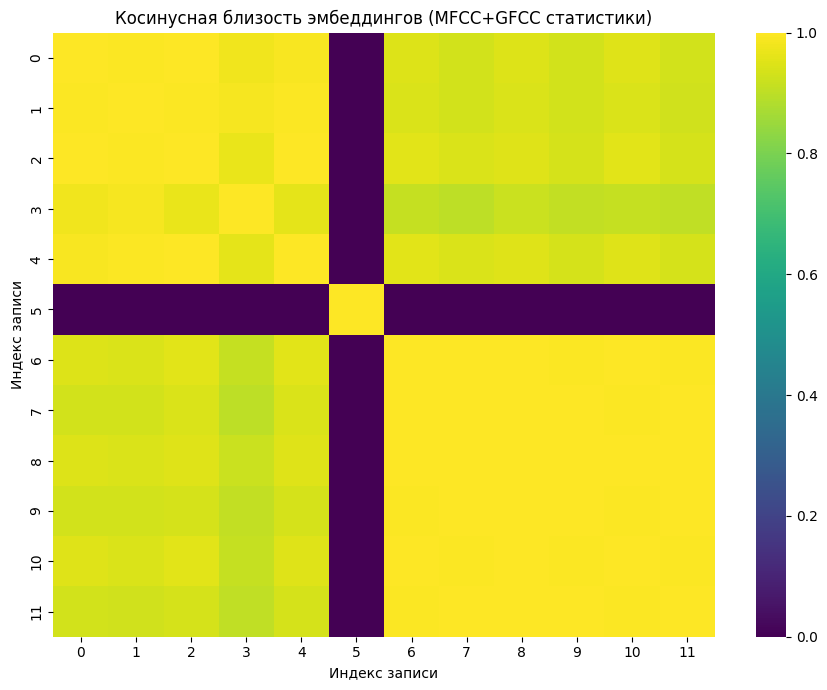

centroid          rolloff          bandwidth           zcr  \
                   mean     std     mean      std      mean     std  mean   
source variant                                                              
guitar clean     926.92    0.71  1321.19    10.05   1407.89    3.27  0.03   
       noisy    4248.50  969.05  8325.07  1125.29   3272.28  110.58  0.22   
violin clean    1430.81   10.14  2633.40    14.53   1015.55   18.68  0.05   
       noisy    2086.62   41.58  3678.93   125.15   2177.41   32.54  0.05   

                       rms        
                 std  mean   std  
source variant                    
guitar clean    0.00  0.06  0.07  
       noisy    0.14  0.16  0.03  
violin clean    0.00  0.48  0.01  
       noisy    0.00  0.48  0.01

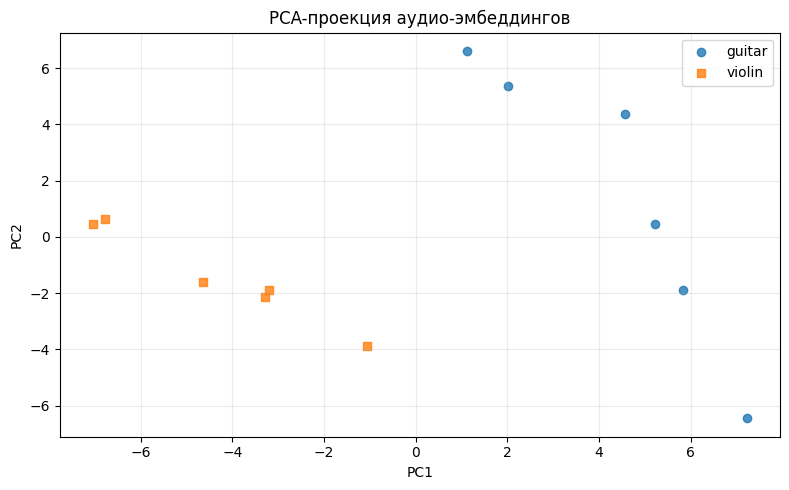

Итог сравнения:
- Средняя внутриклассовая косинусная близость: 0.7508
- Средняя межклассовая косинусная близость:   0.6931
- Если внутриклассовая близость заметно выше межклассовой, то признаки MFCC/GFCC хорошо разделяют источники звука.


In [28]:
# 4) Подробный анализ сходств/различий: таблицы, матрица близости, PCA-проекция
emb_matrix = np.vstack([r["embedding"] for r in records])
clip_ids = [r["clip_id"] for r in records]
sources = [r["source"] for r in records]
variants = [r["variant"] for r in records]

# Косинусная близость между всеми парами записей.
sim_matrix = 1.0 - cdist(emb_matrix, emb_matrix, metric="cosine")

if sns is not None:
    plt.figure(figsize=(9, 7))
    sns.heatmap(sim_matrix, cmap="viridis", vmin=0.0, vmax=1.0)
    plt.title("Косинусная близость эмбеддингов (MFCC+GFCC статистики)")
    plt.xlabel("Индекс записи")
    plt.ylabel("Индекс записи")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(9, 7))
    plt.imshow(sim_matrix, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    plt.title("Косинусная близость эмбеддингов (MFCC+GFCC статистики)")
    plt.xlabel("Индекс записи")
    plt.ylabel("Индекс записи")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Сравнение внутриклассовой и межклассовой близости.
within_vals = []
between_vals = []
for i in range(len(records)):
    for j in range(i + 1, len(records)):
        if sources[i] == sources[j]:
            within_vals.append(sim_matrix[i, j])
        else:
            between_vals.append(sim_matrix[i, j])

within_mean = float(np.mean(within_vals))
between_mean = float(np.mean(between_vals))

# Статистика спектральных признаков по источникам.
group_stats = (
    features_df.groupby(["source", "variant"])[["centroid", "rolloff", "bandwidth", "zcr", "rms"]]
    .agg(["mean", "std"])
    .round(2)
)
display(group_stats)

# PCA в 2D по эмбеддингам для визуального сравнения.
X_scaled = StandardScaler().fit_transform(emb_matrix)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
for source_name, marker in [("guitar", "o"), ("violin", "s")]:
    idx = [k for k, s in enumerate(sources) if s == source_name]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], marker=marker, label=source_name, alpha=0.8)
plt.title("PCA-проекция аудио-эмбеддингов")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("Итог сравнения:")
print(f"- Средняя внутриклассовая косинусная близость: {within_mean:.4f}")
print(f"- Средняя межклассовая косинусная близость:   {between_mean:.4f}")
print(
    "- Если внутриклассовая близость заметно выше межклассовой, "
    "то признаки MFCC/GFCC хорошо разделяют источники звука."
)


Краткие комментарии:

- Вместо двух одиночных файлов построен расширенный пайплайн: сегментация + генерация зашумленных версий, поэтому сравнение проводится на наборе записей, а не на одной паре.
- Для каждой записи считаются спектры, спектрограммы, MFCC и GFCC, а также агрегированные спектральные статистики (`centroid`, `rolloff`, `bandwidth`, `zcr`, `rms`).
- Добавлены две формы сравнения: матрица косинусной близости эмбеддингов и PCA-проекция, что позволяет видеть как внутриклассовое, так и межклассовое разделение.
